#### PCA

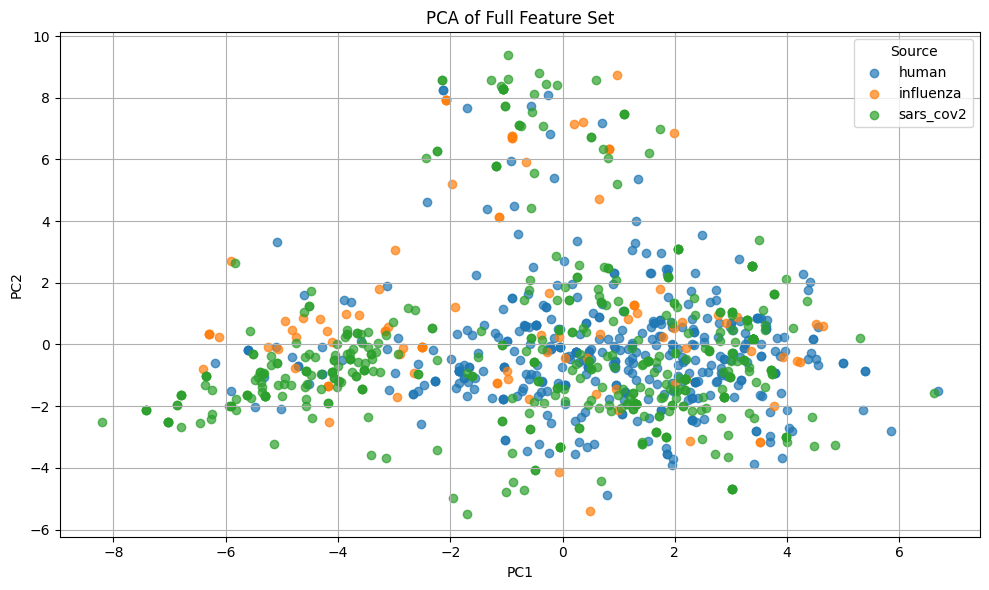

Variance explained by PC1: 6.28%
Variance explained by PC2: 4.74%


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
df = pd.read_csv("../../generated/cdrs/seq/all_data_normalized.tsv", sep="\t")
df

# Step 2: Select all numerical columns (exclude strings or metadata)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# Step 3: Extract feature matrix (including any typo columns)
X = df[numeric_cols].copy()

# Impute missing values with column mean
X_imputed = X.fillna(X.mean())

# Step 4: Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 5: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 6: Create PCA results DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["source"] = df["source"]

# Step 7: Plot PCA result
plt.figure(figsize=(10, 6))
for group in pca_df["source"].unique():
    subset = pca_df[pca_df["source"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Full Feature Set")
plt.legend(title="Source")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Print explained variance
explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]:.2%}")
print(f"Variance explained by PC2: {explained[1]:.2%}")


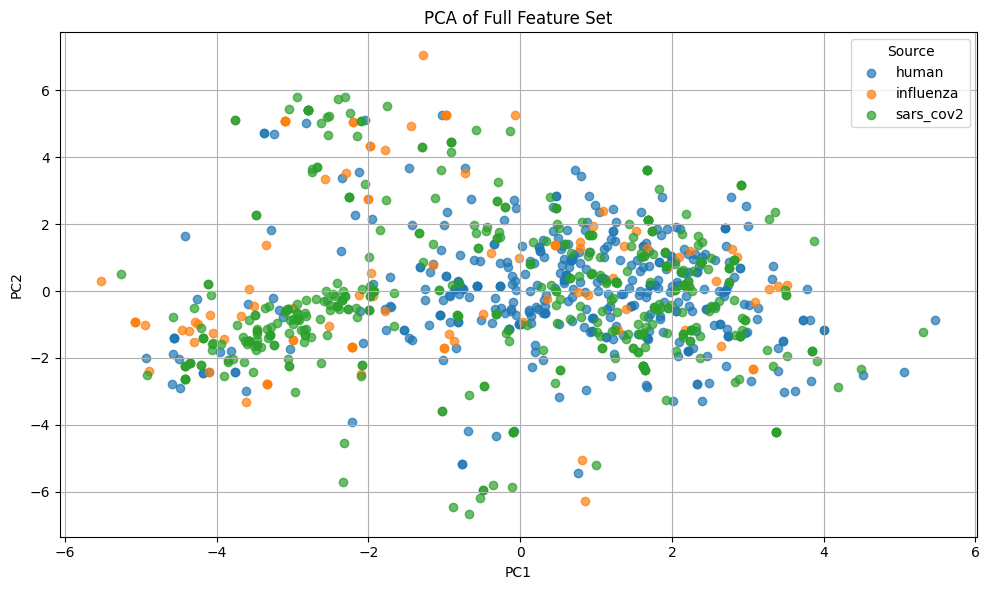

Variance explained by PC1: 6.95%
Variance explained by PC2: 5.45%


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
df = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")
df

# Step 2: Select all numerical columns (exclude strings or metadata)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# Step 3: Extract feature matrix (including any typo columns)
X = df[numeric_cols].copy()

# Impute missing values with column mean
X_imputed = X.fillna(X.mean())

# Step 4: Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 5: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 6: Create PCA results DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["source"] = df["source"]

# Step 7: Plot PCA result
plt.figure(figsize=(10, 6))
for group in pca_df["source"].unique():
    subset = pca_df[pca_df["source"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Full Feature Set")
plt.legend(title="Source")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Print explained variance
explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]:.2%}")
print(f"Variance explained by PC2: {explained[1]:.2%}")


In [2]:
import pandas as pd

# Beispiel: DataFrame laden
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Wir kombinieren alle 3 Sequenzen
df_nm["CDR_all"] = df_nm["CDR_H1"].astype(str) + df_nm["CDR_H2"].astype(str) + df_nm["CDR_H3"].astype(str)
df_nm


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_count_A,CDR_H1_count_R,CDR_H1_count_N,CDR_H1_count_D,CDR_H1_count_C,...,CDR_H3_relfreq_K,CDR_H3_relfreq_M,CDR_H3_relfreq_F,CDR_H3_relfreq_P,CDR_H3_relfreq_S,CDR_H3_relfreq_T,CDR_H3_relfreq_W,CDR_H3_relfreq_Y,CDR_H3_relfreq_V,CDR_all
0,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,0.0,0.000000,0.125000,0.000000,0.000000,0.125000,0.000000,0.000000,0.250000,GFSLDTSGVFWDDDRFVGTLDV
1,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,0.0,0.000000,0.125000,0.000000,0.000000,0.125000,0.000000,0.000000,0.250000,GFSLDTSGVFWDDDRFVGTLDV
2,8znz,F,AIYYYGSSYNYYAMDY,SSGGGY,GFTFSKY,0.0,0.0,0.0,0.0,0.0,...,0.0,0.062500,0.000000,0.000000,0.125000,0.000000,0.000000,0.437500,0.000000,GFTFSKYSSGGGYAIYYYGSSYNYYAMDY
3,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,0.250000,0.000000,GFNVSYYYPYYGSGYGWALDY
4,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.125000,0.250000,0.000000,GFNVSYYYPYYGSGYGWALDY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN,0.0,0.0,1.0,0.0,0.0,...,0.0,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,GFTVSSNYSGGSDLQEHGMDV
957,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.083333,0.333333,0.000000,0.000000,0.166667,0.000000,GYSFISYYPGDSDLLYYSDSSPLDS
958,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.071429,0.071429,0.214286,0.000000,0.000000,0.071429,0.000000,GFTFMSSVIGSGNPYCSSISCNDGFDI
959,7n3d,H,HSRIEVAGTLDFDY,YYSGN,GGSISSY,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.071429,0.000000,0.071429,0.071429,0.000000,0.071429,0.071429,GGSISSYYYSGNHSRIEVAGTLDFDY


In [3]:
import numpy as np

# Alphabet + Padding-Zeichen
aa_list = list("ACDEFGHIKLMNPQRSTVWY-")
aa_to_idx = {aa: i for i, aa in enumerate(aa_list)}

# Padding auf gleiche Länge
max_len = df_nm["CDR_all"].str.len().max()
padded = df_nm["CDR_all"].apply(lambda x: x.ljust(max_len, "-"))

# One-Hot-Matrix erzeugen
onehot = np.zeros((len(df_nm), max_len * len(aa_list)))

for i, seq in enumerate(padded):
    for j, aa in enumerate(seq):
        idx = aa_to_idx.get(aa, aa_to_idx["-"])
        onehot[i, j * len(aa_list) + idx] = 1

onehot

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

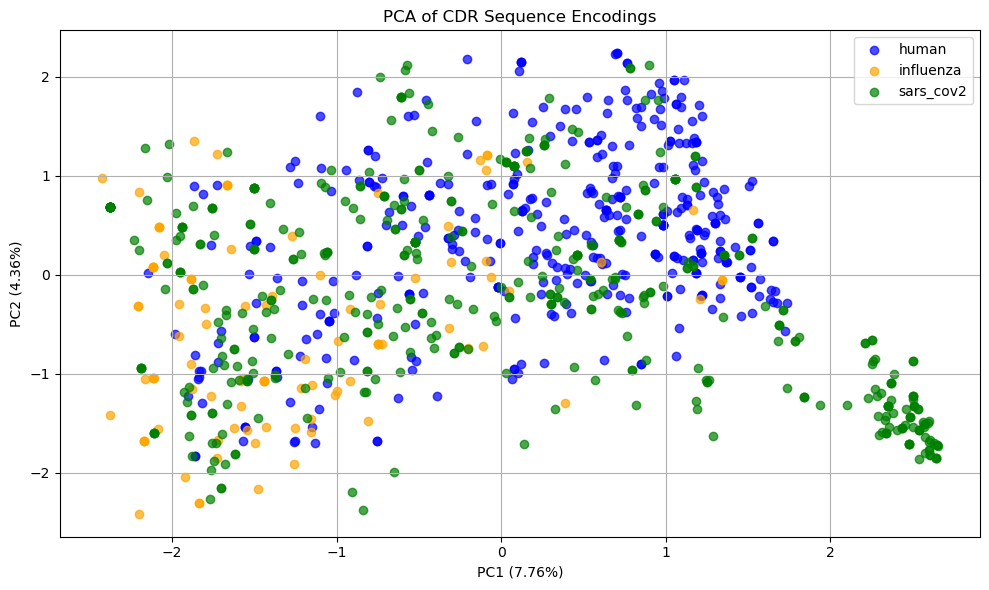

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(onehot)

# Quelle als Farbe
colors = {"human": "blue", "influenza": "orange", "sars_cov2": "green"}
group_labels = df_nm["source"].values

plt.figure(figsize=(10, 6))
for group in np.unique(group_labels):
    idx = group_labels == group
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=group, alpha=0.7, color=colors.get(group, "gray"))

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA of CDR Sequence Encodings")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


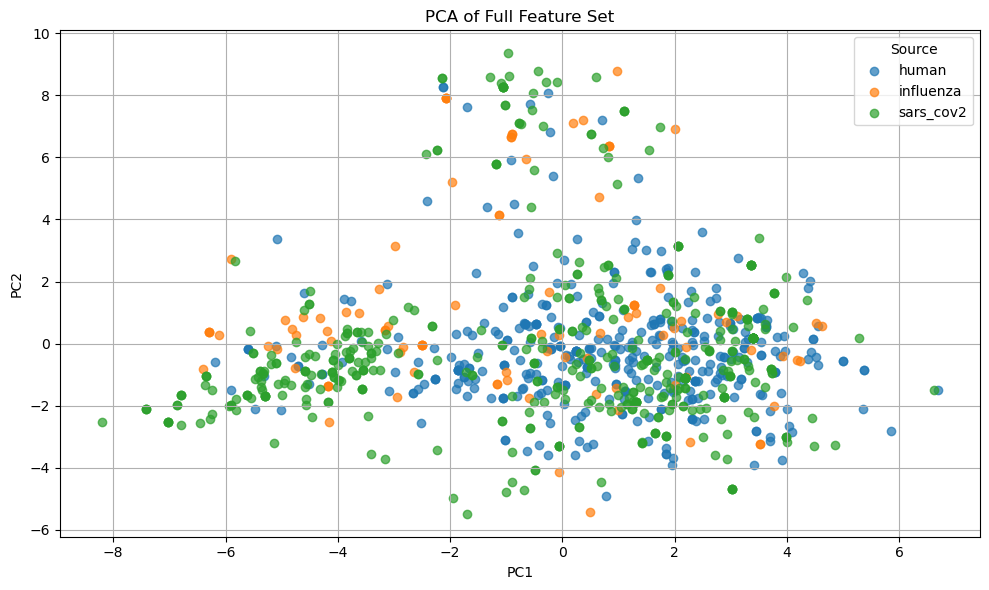

Variance explained by PC1: 6.28%
Variance explained by PC2: 4.74%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Step 2: Select all numerical columns (exclude strings or metadata)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# Step 3: Extract feature matrix (including any typo columns)
X = df[numeric_cols].copy()

# Step 4: Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Step 6: Create PCA results DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["source"] = df["source"]

# Step 7: Plot PCA result
plt.figure(figsize=(10, 6))
for group in pca_df["source"].unique():
    subset = pca_df[pca_df["source"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Full Feature Set")
plt.legend(title="Source")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Print explained variance
explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]:.2%}")
print(f"Variance explained by PC2: {explained[1]:.2%}")


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap  # UMAP import
%pip install umap-learn

# Step 1: Load the dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Step 2: Select numerical columns (exclude metadata/strings)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

# Step 3: Feature matrix
X = df[numeric_cols].copy()

# Step 4: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: UMAP projection
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.scatter(X_umap[:, 0], X_umap[:, 1], marker='o', alpha=0.5, c=color)


ModuleNotFoundError: No module named 'umap'